<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de Linguagem Natural

## Embeddings - Prática

# 1- Usando Word embeddings pré-treinadas

Algumas opções de word embeddings pré-treinadas para o portugues são:


*   Word embeddings monolíngues (ex: NILC word embeddings - disponíveis em http://nilc.icmc.usp.br/embeddings)
*   Word embeddings multilíngues (ex: MUSE word embeddings - disponíveis em http://github.com/facebookresearch/MUSE)

Foram escolhidas as word embeddings do NILC treinadas com GloVe conforme informações disponíveis na página do NILC word embeddings citada acima.



In [1]:
!pip install torch pot gensim transformers # depois de rodar a 1 vez, pode comentar essa linha

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.3 MB/s eta 0:00:00


In [2]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.pt.300.vec.gz -O cc.pt.300.vec.gz

--2026-02-19 00:24:58--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.pt.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.33, 13.249.182.62, 13.249.182.39, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1271093660 (1.2G) [binary/octet-stream]
Saving to: ‘cc.pt.300.vec.gz’

cc.pt.300.vec.gz    100%[===================>]   1.18G  37.8MB/s    in 27s     

2026-02-19 00:25:25 (45.7 MB/s) - ‘cc.pt.300.vec.gz’ saved [1271093660/1271093660]



In [3]:
!gunzip cc.pt.300.vec.gz

In [4]:
import gensim

In [5]:
nilc_glove = gensim.models.KeyedVectors.load_word2vec_format("cc.pt.300.vec")

In [6]:
nilc_glove["rainha"]

array([-0.0456, -0.0181,  0.0177,  0.0171, -0.039 , -0.1177,  0.0562,
       -0.0157,  0.0142, -0.0686,  0.0538, -0.091 , -0.0113, -0.0478,
        0.0076, -0.0171,  0.0736,  0.1361,  0.0238, -0.0273, -0.0396,
       -0.0138, -0.088 , -0.0807, -0.0403,  0.0225,  0.0848, -0.076 ,
        0.0342,  0.0401, -0.0307,  0.0507,  0.0099, -0.0142, -0.0313,
        0.0623,  0.0314,  0.0489, -0.0693, -0.0033, -0.0571,  0.1319,
       -0.025 , -0.0763,  0.0137,  0.0269, -0.0838, -0.0276,  0.0262,
        0.0285, -0.0147, -0.042 , -0.0463, -0.0193,  0.0422, -0.0572,
        0.022 ,  0.0742, -0.0993,  0.096 , -0.0457, -0.0572, -0.0366,
        0.0391,  0.0604, -0.0382,  0.0731, -0.0742,  0.052 ,  0.0499,
       -0.02  ,  0.0335,  0.0233, -0.0227, -0.0153, -0.0482,  0.0569,
       -0.0123, -0.0174,  0.0026,  0.0108,  0.0612, -0.0622,  0.0171,
       -0.037 , -0.0553, -0.1358,  0.0644, -0.0396, -0.0565,  0.1182,
       -0.0098, -0.0332,  0.1364,  0.0029,  0.0276, -0.0263,  0.083 ,
        0.0248,  0.0

In [7]:
nilc_glove.similarity("rei", "rainha").item()

0.6306386590003967

# Verificando a similaridade entre palavras

Nesta seção faremos algumas manipulações básicas com as WEs do NILC para encontrar a similaridade entre palavras.
Por exemplo, a operação abaixo

resultado = vetor[mulher] + vetor[rei] - vetor[homem]

o vetor mais próximo do resultado é o vetor de "rainha".

In [8]:
resultado = nilc_glove.most_similar(positive=["mulher", "rei"], negative=["homem"], topn=5)

for palavra, score in resultado:
    print(f"{palavra} : {score:.4f}")

rainha : 0.7363
princesa : 0.6032
rainha-mãe : 0.5877
súdita : 0.5833
rainha-consorte : 0.5824


In [9]:
resultado2 = nilc_glove.most_similar(positive=['amar', 'odiando'], negative=['odiar'], topn=5)

for palavra, score in resultado2:
    print(f"{palavra} : {score:.4f}")

amando : 0.7551
amando-se : 0.6246
amando-o : 0.6094
amando-a : 0.6086
amando-os : 0.5702


Também podemos conferir quais são as n palavras mais próximas (o default do most_similar é n=10) de uma determinada palavra, por exemplo: "escola".

In [10]:
nilc_glove.most_similar("escola")

[('daescola', 0.7470125555992126),
 ('aescola', 0.7394051551818848),
 ('escola.A', 0.7387107610702515),
 ('naescola', 0.7174085974693298),
 ('umaescola', 0.7141104340553284),
 ('escola.E', 0.7139132618904114),
 ('ex-escola', 0.706774890422821),
 ('escolar', 0.7016416192054749),
 ('escolaA', 0.7008737921714783),
 ('escola.É', 0.6975688934326172)]

também é possível calcular o valor de similaridade (usando cosseno, por default) entre duas palavras.

In [11]:
print("Similaridade entre menino e menina: ", nilc_glove.similarity("menino", "menina"))

Similaridade entre menino e menina:  0.7075304


E verificar qual palavra distoa em um grupo de quatro palavras, por exemplo: menina, menino, cão e garota.

In [13]:
print(nilc_glove.doesnt_match("menina menino cão garota".split()))

cão


# Verificando a similaridade entre sentenças

Além de verificar a similaridade entre palavras, o gensim disponibiliza algumas rotinas para calcular a similaridade entre as sentenças. Por exemplo, a similaridade da sentença "O menino foi para a escola de ônibus". e as sentenças "Ana foi para a escola ontem". e "A menina foi para casa". Veja que a similaridade com a última é maior do que com a primeira.

In [14]:
sentenca = "O menino foi para a escola de ônibus".lower().split()

sent1 = "Ana foi para a escola ontem".lower().split()
similaridade = nilc_glove.wmdistance(sentenca, sent1)
print("{:.4f}".format(similaridade))

sent2 = "A menina foi para casa".lower().split()
similaridade = nilc_glove.wmdistance(sentenca, sent2)
print("{:.4f}".format(similaridade))

0.6331
0.6827


# BERTimbau

Modelo de linguagem contextualizado para o portugues

In [15]:
import torch
from transformers import BertTokenizer
from transformers import BertForPreTraining
from transformers import BertModel

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

tokenizer = BertTokenizer.from_pretrained('neuralmind/bert-large-portuguese-cased', do_lower_case=False)
bert = BertModel.from_pretrained('neuralmind/bert-large-portuguese-cased').to(device)


cuda


tokenizer_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-large-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
texto = "Eu vou ao banco pagar a conta hoje."

# Tokenizando o texto
input_ids = tokenizer.encode(texto, return_tensors='pt')
wordpieces = tokenizer.convert_ids_to_tokens(input_ids[0])

# salvando ponteiros para palavras
subwords_idx = []
for i, wordpiece in enumerate(wordpieces):
  if '##' not in wordpiece and i not in [0, len(wordpieces)-1]:
    subwords_idx.append(i)

# Obtendo os vetores para as palavras
input_ids = input_ids.to(device)
with torch.no_grad():
  outs = bert(input_ids)
  vetores = outs[0][0, :]

print(vetores[subwords_idx].size(), '\n')
vetores[subwords_idx]

torch.Size([9, 1024]) 



tensor([[ 0.7381,  0.6351,  0.4160,  ..., -0.5735, -0.9812, -0.6793],
        [ 0.6583, -0.0975,  0.2579,  ..., -0.7367, -0.8734,  0.1407],
        [ 0.7682,  0.2151,  0.1769,  ...,  1.0626, -0.2526, -0.3107],
        ...,
        [-0.0765,  0.4402, -0.5236,  ...,  0.8389, -0.3389, -0.8167],
        [ 0.3460,  1.8568, -0.0262,  ..., -0.0021, -0.0928,  0.0079],
        [ 0.8516,  1.1038, -1.1464,  ...,  0.4630, -0.4967,  0.2980]],
       device='cuda:0')

# Gerando sua próprias word embeddings

Agora vamos gerar WEs para um corpus. Veja que todas as rotinas e os cálculos apresentados anteriormente continuam aplicáveis com as novas WEs

# O Corpus

Utilizando os dados de um desafio do Kaggle para análise de sentimentos, em portugues

https://www.kaggle.com/augustop/portuguese-tweets-for-sentiment-analysis

In [19]:
!wget https://www.dropbox.com/s/bdr4tmkxcvk9pqc/NothemeTweets.csv.zip?dl=1 -O NothemeTweets.csv.zip
!unzip -o NothemeTweets.csv.zip

--2026-02-19 01:23:46--  https://www.dropbox.com/s/bdr4tmkxcvk9pqc/NothemeTweets.csv.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/5e5rqr2bs6kug395j2mo1/NothemeTweets.csv.zip?rlkey=0livqk4f276e6ychb1duvu8p4&dl=1 [following]
--2026-02-19 01:23:46--  https://www.dropbox.com/scl/fi/5e5rqr2bs6kug395j2mo1/NothemeTweets.csv.zip?rlkey=0livqk4f276e6ychb1duvu8p4&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc488773ebfbca32883d14d46d1b.dl.dropboxusercontent.com/cd/0/inline/C7JRom-pDeHedF51vxDjIcLKiyzK3i5ybqjZ-4_tW-N3CwYIzG4n1642JRnfpjIDvcGrby9EORlJDwSqbvgD-GJWB1SAPhIpSCvKcP9WX8futcVuRElB85Mzajf_uwwG4iA/file?dl=1# [following]
--2026-02-19 01:23:47--  https://uc488773ebfbca32883d14d46d1b.dl.dropboxus

Usando o pandas para visualizar os campos do arquivo .csv

In [22]:
import pandas as pd
corpus = pd.read_csv("NoThemeTweets.csv", sep=',')
corpus.head(10)

,id,tweet_text,tweet_date,sentiment,query_used
0,1031761728445530112,@Tixaa23 14 para eu ir :),Tue Aug 21 04:35:39 +0000 2018,Positivo,:)
1,1031761040462278656,@drexalvarez O meu like eu já dei na época :),Tue Aug 21 04:32:55 +0000 2018,Positivo,:)
2,1031760962372689920,Eu só queria conseguir comer alguma coisa pra ...,Tue Aug 21 04:32:37 +0000 2018,Positivo,:)
3,1031760948250456066,:D que lindo dia !,Tue Aug 21 04:32:33 +0000 2018,Positivo,:)
4,1031760895985246208,"@Primo_Resmungao Pq da pr jeito!!é uma ""oferta...",Tue Aug 21 04:32:21 +0000 2018,Positivo,:)
5,1031760822543020032,"@BadWolf_Wagner @DanieVedo Eu entendi, mas iss...",Tue Aug 21 04:32:03 +0000 2018,Positivo,:)
6,1031760780641718272,@Chyko661 @g1 [+] Carcinoma Hepatico (Cancer d...,Tue Aug 21 04:31:53 +0000 2018,Positivo,:)
7,1031760749813805058,"Aquela mina da limpeza, que tinha um marido co...",Tue Aug 21 04:31:46 +0000 2018,Positivo,:)
8,1031760690778976262,"@narryfools aqui, espero que você melhore logo...",Tue Aug 21 04:31:32 +0000 2018,Positivo,:)
9,1031760658600284160,@fefocaires se és feliz trabalhando nisso entã...,Tue Aug 21 04:31:24 +0000 2018,Positivo,:)


Vamos utilizar somente o campo tweet_text, que contém os tweets, nosso objeto de interesse. Por exemplo, o terceiro tweet é acessado na posição 2 (as posições começam no 0)

In [24]:
tweets = corpus["tweet_text"].values
tweets[2]

'Eu só queria conseguir comer alguma coisa pra poder dormir :)'

# Processamento Básico

Neste processamento, utilizaremos a biblioteca NLTK

In [25]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('portuguese')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Primeiro, vamos "ler" e armazenar todas as sentenças (tweets) do corpus, convertendo as palavras para minúsculas e removendo stopwords e tokens que não tenham letras nem números.

In [27]:
nltk.download('punkt_tab')
sentencas = []
for tweet in tweets:
  tokens = nltk.word_tokenize(tweet)
  processada = [w.lower() for w in tokens if not w in stopwords and w.isalnum()]
  sentencas.append(processada)
len(sentencas)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


785814

In [28]:
sentencas[2]

['eu',
 'queria',
 'conseguir',
 'comer',
 'alguma',
 'coisa',
 'pra',
 'poder',
 'dormir']

# Gerando Word Embeddings

In [30]:
from gensim.models import Word2Vec
meu_modelo = Word2Vec(sentencas,
                      min_count=3,
                      vector_size=300,
                      workers=2,
                      window=5,
                      epochs=30)

In [31]:
len(meu_modelo.wv.index_to_key)

83545

In [32]:
print(meu_modelo.wv.key_to_index)

{'https': 0, 'pra': 1, 'q': 2, 'queria': 3, 'to': 4, 'vou': 5, 'eu': 6, 'd': 7, 'vai': 8, 'vc': 9, 'bem': 10, 'n': 11, 'dia': 12, 'ter': 13, 'p': 14, 'pq': 15, 'triste': 16, 'tá': 17, 'amo': 18, 'tô': 19, 'tudo': 20, 'tão': 21, 'agora': 22, 'nao': 23, 'quero': 24, 'ver': 25, 'gente': 26, 'ai': 27, 'fazer': 28, 'ainda': 29, 'não': 30, 'aqui': 31, 'hoje': 32, 'sei': 33, 'bom': 34, 'sim': 35, 'nada': 36, 'ir': 37, 'tanto': 38, 'assim': 39, 'mim': 40, 'ta': 41, 'acho': 42, 'o': 43, 'sempre': 44, 'coisa': 45, 'mt': 46, 'amor': 47, 'nunca': 48, 'vida': 49, 'ficar': 50, 'a': 51, 'tava': 52, 'e': 53, 'alguém': 54, 'demais': 55, 'aí': 56, 'mas': 57, 'todo': 58, 'casa': 59, 'faz': 60, 'lá': 61, 'obrigada': 62, 'boa': 63, 'que': 64, 'melhor': 65, 'pode': 66, 'mundo': 67, 'feliz': 68, 'deus': 69, 'tempo': 70, 'é': 71, 'mano': 72, 'pessoas': 73, 'saudade': 74, 'dar': 75, 'saudades': 76, 'porque': 77, 'fico': 78, 'eh': 79, 'dormir': 80, 'mal': 81, 'então': 82, 'pessoa': 83, 'todos': 84, 'cara': 85, 

Nessas novas WEs, as palavras mais similares à escola são:

In [33]:
meu_modelo.wv.most_similar("escola")

[('faculdade', 0.6138341426849365),
 ('facul', 0.5149542689323425),
 ('sala', 0.495029091835022),
 ('aula', 0.48644882440567017),
 ('colégio', 0.4821065664291382),
 ('academia', 0.4652164578437805),
 ('casa', 0.45503106713294983),
 ('escolinha', 0.4458965063095093),
 ('uni', 0.41444462537765503),
 ('curso', 0.3920023441314697)]

# Salvando as Word Embeddings geradas

Por fim, podemos salvar o modelo treinado para ser carregado para uso futuro (de modo similar ao que fizemos na parte 1 desse código). É importante salvar o modelo.

In [35]:
meu_modelo.wv.save_word2vec_format("meu_modelo.bin", binary=True)

# Visualizando as word Embeddings

Uma das coisas mais legais de se fazer com as WEs é plotar em duas dimensões e analisar visualmente a distância entre as palavras.

In [36]:
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('classic')
from sklearn.decomposition import PCA

In [37]:
def display_pca_scatterplot(model, words):
  word_vectors = np.array([model[w] for w in words])

  twodim = PCA().fit_transform(word_vectors)[:, :2]

  plt.figure(figsize=(6, 6))
  plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
  for word, (x, y) in zip(words, twodim):
    plt.text(x+0.05, y+0.05, word)

In [38]:
meu_modelo.wv.most_similar('escola')

[('faculdade', 0.6138341426849365),
 ('facul', 0.5149542689323425),
 ('sala', 0.495029091835022),
 ('aula', 0.48644882440567017),
 ('colégio', 0.4821065664291382),
 ('academia', 0.4652164578437805),
 ('casa', 0.45503106713294983),
 ('escolinha', 0.4458965063095093),
 ('uni', 0.41444462537765503),
 ('curso', 0.3920023441314697)]

Plotando o vetor da palavra "escola" e as 10 palavras mais próximas a ele, de acordo com o modelo que acabamos de treinar.

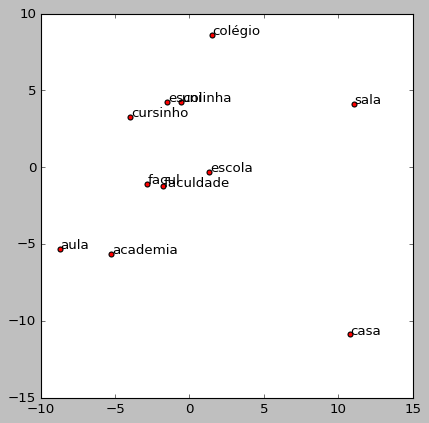

In [39]:
words = ['escola', 'faculdade', 'facul', 'aula', 'sala', 'colégio', 'academia', 'casa', 'escolinha', 'uni', 'cursinho']
display_pca_scatterplot(meu_modelo.wv, words)

In [40]:
nilc_glove.most_similar('escola')

[('daescola', 0.7470125555992126),
 ('aescola', 0.7394051551818848),
 ('escola.A', 0.7387107610702515),
 ('naescola', 0.7174085974693298),
 ('umaescola', 0.7141104340553284),
 ('escola.E', 0.7139132618904114),
 ('ex-escola', 0.706774890422821),
 ('escolar', 0.7016416192054749),
 ('escolaA', 0.7008737921714783),
 ('escola.É', 0.6975688934326172)]

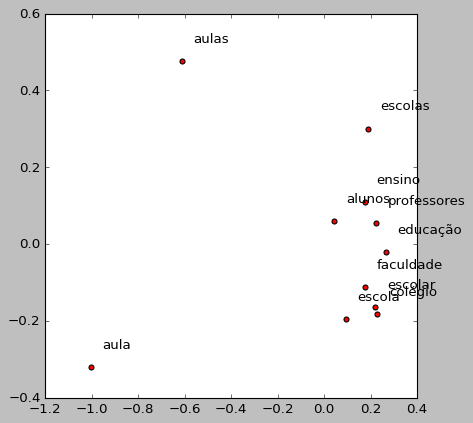

In [42]:
words = ['escola', 'alunos', 'escolas', 'ensino', 'colégio', 'faculdade', 'aula', 'aulas', 'educação', 'professores', 'escolar']
display_pca_scatterplot(nilc_glove, words)